![](img/banner.png)
%%HTML
<script src="require.js"></script>

# Image Segmentation: Comparing Thresholding, Naive Bayes, and k-NN

This educational module demonstrates three different approaches to image segmentation:

1. Fixed Thresholding
A simple rule-based method where pixels are classified based on a predetermined intensity threshold.

2. Naive Bayes Classifier
A probabilistic approach that assumes pixel intensities follow Gaussian distributions for each class. The algorithm learns the parameters (mean and variance) from training data and applies Bayes' theorem for classification.

3. k-Nearest Neighbors (k-NN)
A distance-based method that classifies pixels based on the majority vote of their k-nearest neighbors in the feature space.

## Learning Objectives:
- Understand the trade-offs between simple thresholding and machine learning approaches
- Compare parametric (Naive Bayes) vs non-parametric (k-NN) methods
- Learn how to extract and use training samples for supervised segmentation
- Visualize probability distributions and decision boundaries

## Key Concepts:

- Supervised Learning: Using labeled data to train classifiers
- Feature Extraction: Using pixel intensity and spatial coordinates
- Probability Maps: Visualizing classification confidence
- Model Assumptions: Gaussian distributions vs local similarity

Image Segmentation: Fixed Threshold vs Naive Bayes vs k-NN
Creating test image with ground truth...
Sampling training pixels...
Visualizing training data and distributions...


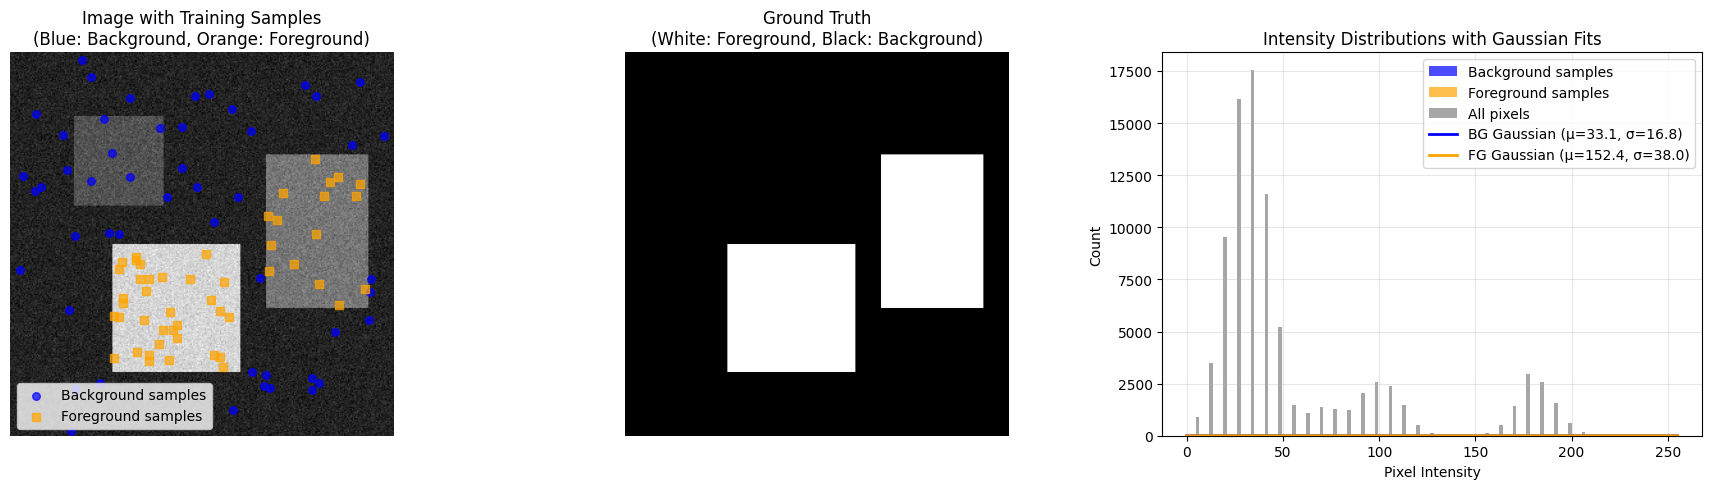

Background samples: 50
Foreground samples: 50
Background - Mean: 33.06, Std: 16.81
Foreground - Mean: 152.44, Std: 38.00
Comparing segmentation methods...


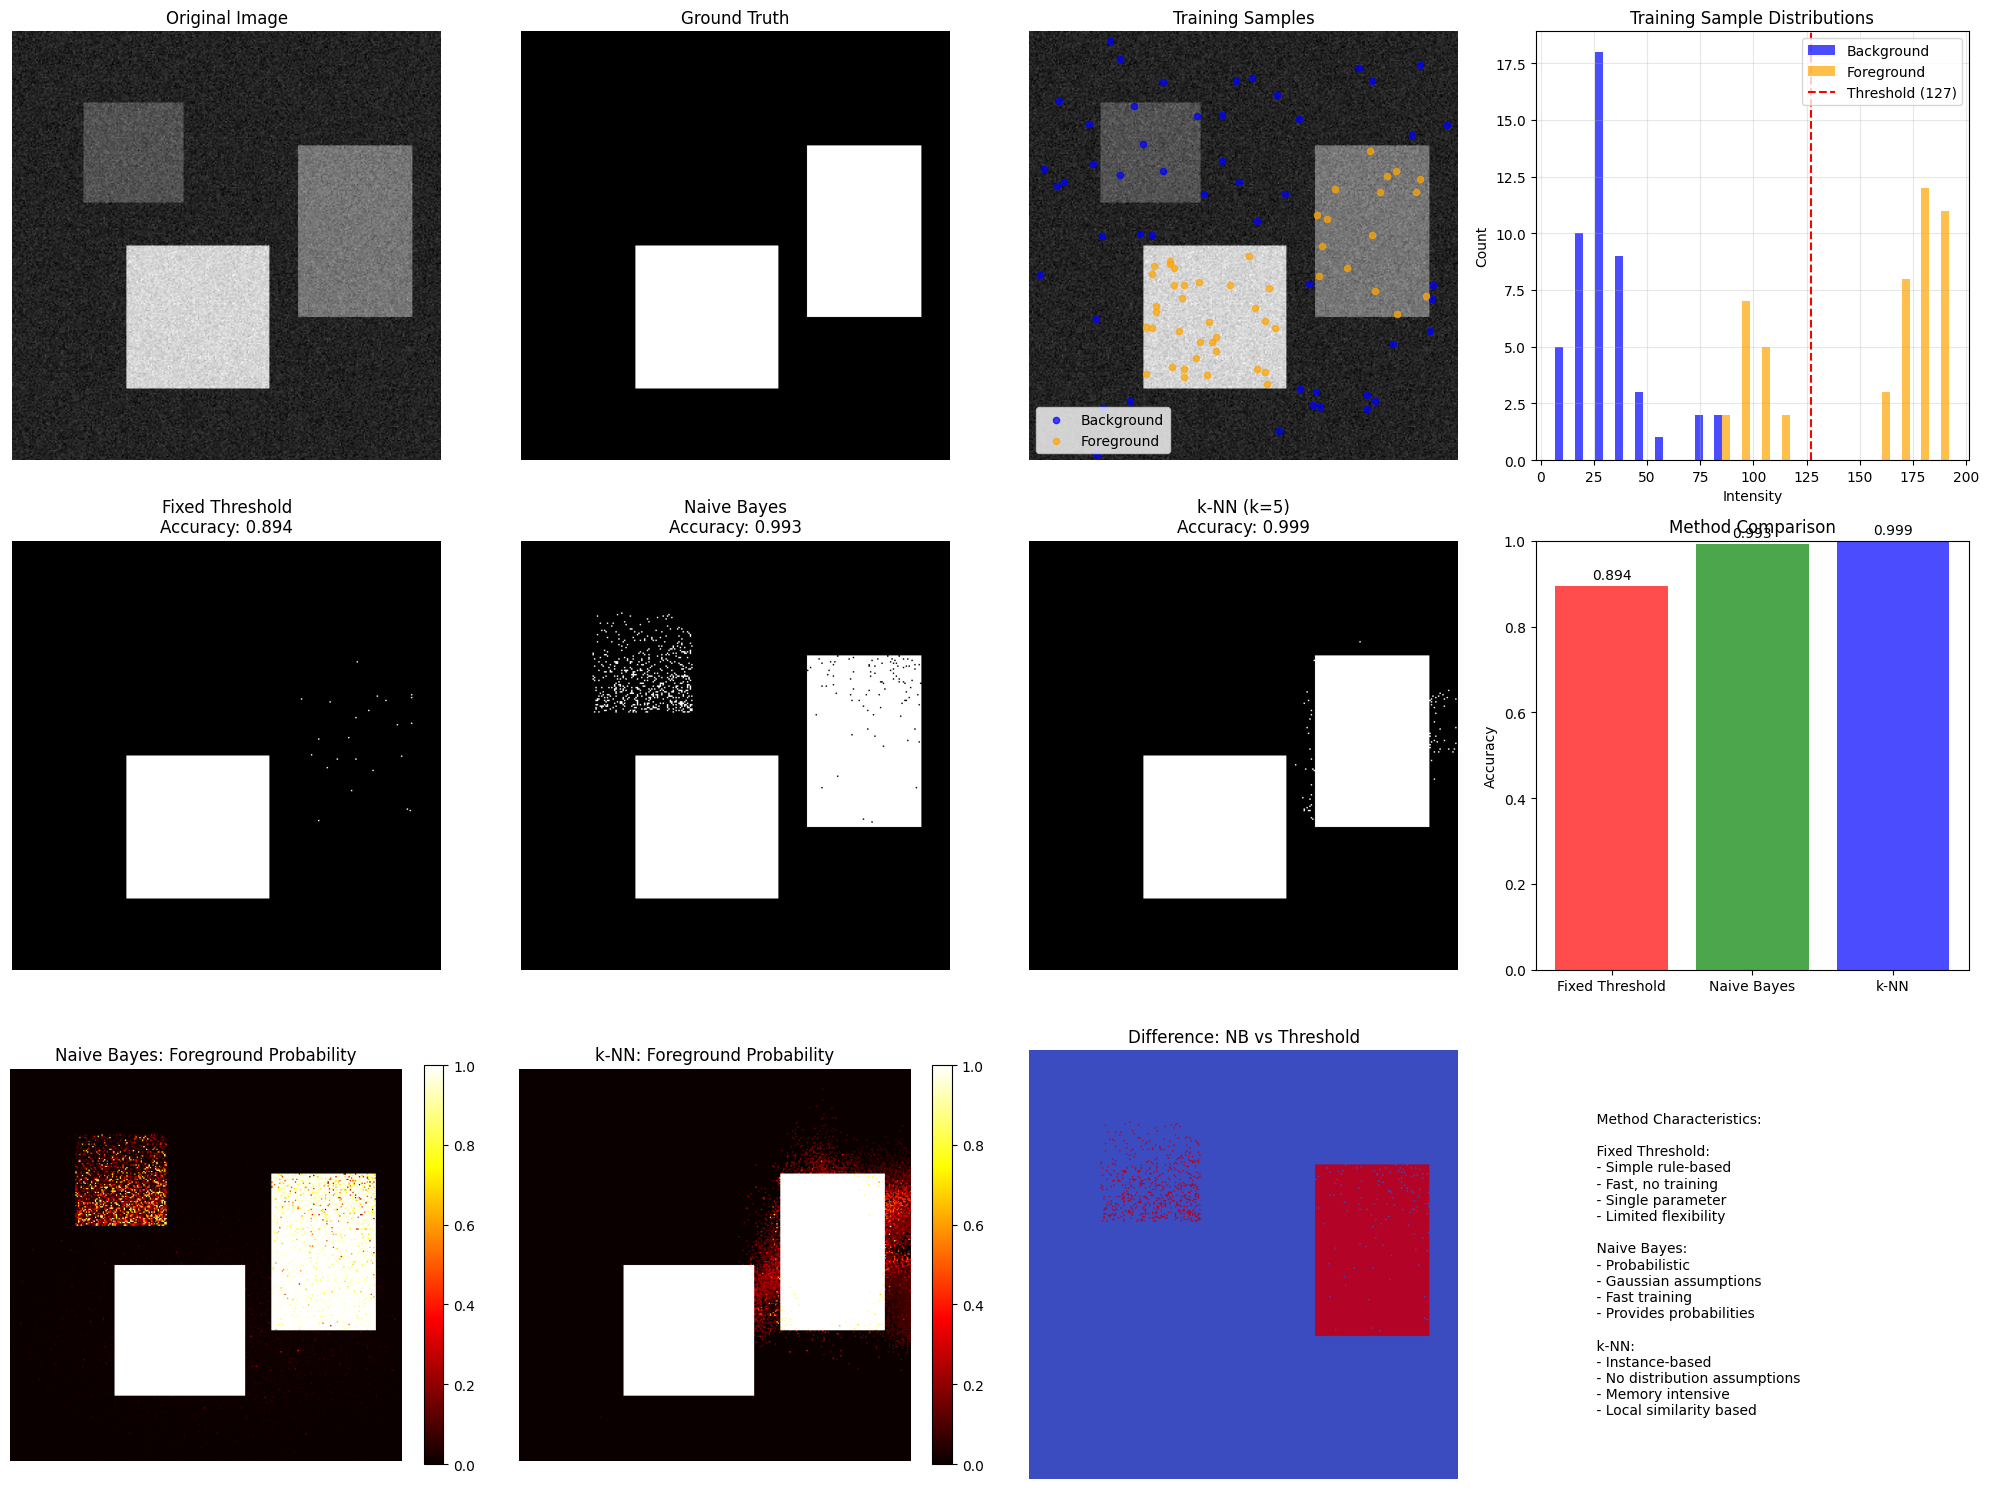


FINAL RESULTS SUMMARY
Fixed Threshold Accuracy: 0.894
Naive Bayes Accuracy:    0.993
k-NN Accuracy:           0.999


In [3]:
# --- Cell 1: Import Libraries ---
import numpy as np
import matplotlib.pyplot as plt
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
from PIL import Image
import cv2
from skimage import data, segmentation
from scipy.stats import norm
import requests
from io import BytesIO

# --- Cell 2: Create Test Image with Known Ground Truth ---
def create_test_image_with_ground_truth(size=(300, 300)):
    """
    Create a test image with known ground truth segmentation
    """
    # Create image
    image = np.full(size, 30, dtype=np.uint8)  # Dark background
    
    # Define regions with known labels
    # Background regions (label 0)
    image[50:120, 50:120] = 70    # Dark rectangle - BACKGROUND
    
    # Foreground regions (label 1)
    image[150:250, 80:180] = 180  # Bright rectangle - FOREGROUND
    image[80:200, 200:280] = 100  # Medium rectangle - FOREGROUND
    
    # Add some Gaussian noise for realism
    noise = np.random.normal(0, 10, size)
    image = np.clip(image.astype(np.float64) + noise, 0, 255).astype(np.uint8)
    
    # Create ground truth mask
    ground_truth = np.zeros(size, dtype=int)
    ground_truth[150:250, 80:180] = 1   # Bright rectangle - FOREGROUND
    ground_truth[80:200, 200:280] = 1   # Medium rectangle - FOREGROUND
    # Everything else is BACKGROUND (label 0)
    
    return image, ground_truth

def sample_training_pixels(image, ground_truth, n_samples_per_class=50):
    """
    Sample training pixels from the image using ground truth
    """
    # Get coordinates for each class
    bg_coords = np.argwhere(ground_truth == 0)
    fg_coords = np.argwhere(ground_truth == 1)
    
    # Randomly sample from each class
    np.random.seed(42)
    if len(bg_coords) > n_samples_per_class:
        bg_samples = bg_coords[np.random.choice(len(bg_coords), n_samples_per_class, replace=False)]
    else:
        bg_samples = bg_coords
    
    if len(fg_coords) > n_samples_per_class:
        fg_samples = fg_coords[np.random.choice(len(fg_coords), n_samples_per_class, replace=False)]
    else:
        fg_samples = fg_coords
    
    # Combine samples
    train_coords = np.vstack([bg_samples, fg_samples])
    train_labels = np.hstack([np.zeros(len(bg_samples)), np.ones(len(fg_samples))])
    
    return train_coords, train_labels.astype(int)

# --- Cell 3: Data Preparation Function ---
def prepare_data(image, train_coords, train_labels):
    """
    Prepare training and test data for classifiers
    """
    # Prepare training data
    X_train = []
    for (y, x), label in zip(train_coords, train_labels):
        intensity = image[y, x]
        X_train.append([intensity, x, y])  # Intensity + spatial coordinates
    
    X_train = np.array(X_train)
    y_train = train_labels
    
    # Prepare test data (all pixels in the image)
    h, w = image.shape
    coordinates = np.array([[y, x] for y in range(h) for x in range(w)])
    intensities = image.flatten()
    
    X_test = np.column_stack([intensities, coordinates[:, 1], coordinates[:, 0]])
    
    return X_train, y_train, X_test, coordinates, intensities

# --- Cell 4: Fixed Threshold Segmentation ---
def fixed_threshold_segmentation(image, threshold=100):
    """
    Perform segmentation using fixed intensity threshold
    """
    segmentation_result = (image > threshold).astype(int)
    return segmentation_result

# --- Cell 5: Naive Bayes Segmentation ---
def naive_bayes_segmentation(X_train, y_train, X_test, image_shape):
    """
    Perform segmentation using Naive Bayes classifier
    """
    # Train Naive Bayes classifier
    nb_classifier = GaussianNB()
    nb_classifier.fit(X_train, y_train)
    
    # Predict all pixels
    nb_predictions = nb_classifier.predict(X_test)
    nb_segmentation = nb_predictions.reshape(image_shape)
    
    # Get probability maps
    nb_probabilities = nb_classifier.predict_proba(X_test)
    nb_bg_prob = nb_probabilities[:, 0].reshape(image_shape)
    nb_fg_prob = nb_probabilities[:, 1].reshape(image_shape)
    
    return nb_segmentation, nb_bg_prob, nb_fg_prob, nb_classifier

# --- Cell 6: k-NN Segmentation ---
def knn_segmentation(X_train, y_train, X_test, image_shape, k=5):
    """
    Perform segmentation using k-NN classifier
    """
    # Train k-NN classifier
    knn_classifier = KNeighborsClassifier(n_neighbors=k, weights='distance')
    knn_classifier.fit(X_train, y_train)
    
    # Predict all pixels
    knn_predictions = knn_classifier.predict(X_test)
    knn_segmentation = knn_predictions.reshape(image_shape)
    
    # Get probability maps
    knn_probabilities = knn_classifier.predict_proba(X_test)
    knn_bg_prob = knn_probabilities[:, 0].reshape(image_shape)
    knn_fg_prob = knn_probabilities[:, 1].reshape(image_shape)
    
    return knn_segmentation, knn_bg_prob, knn_fg_prob, knn_classifier

# --- Cell 7: Visualize Training Samples and Distributions ---
def visualize_training_samples_and_distributions(image, train_coords, train_labels, ground_truth):
    """
    Visualize the image with training samples and intensity distributions
    """
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    
    # Original image with training samples
    axes[0].imshow(image, cmap='gray')
    
    # Plot training samples
    bg_mask = train_labels == 0
    fg_mask = train_labels == 1
    
    axes[0].scatter(train_coords[bg_mask, 1], train_coords[bg_mask, 0], 
                   c='blue', s=30, label='Background samples', alpha=0.7, marker='o')
    axes[0].scatter(train_coords[fg_mask, 1], train_coords[fg_mask, 0], 
                   c='orange', s=30, label='Foreground samples', alpha=0.7, marker='s')
    axes[0].set_title('Image with Training Samples\n(Blue: Background, Orange: Foreground)')
    axes[0].legend()
    axes[0].axis('off')
    
    # Ground truth
    axes[1].imshow(ground_truth, cmap='gray')
    axes[1].set_title('Ground Truth\n(White: Foreground, Black: Background)')
    axes[1].axis('off')
    
    # Enhanced histogram with Gaussian distributions
    all_intensities = image.flatten()
    bg_intensities = [image[y, x] for (y, x), label in zip(train_coords, train_labels) if label == 0]
    fg_intensities = [image[y, x] for (y, x), label in zip(train_coords, train_labels) if label == 1]
    
    # Plot histogram
    n, bins, patches = axes[2].hist([bg_intensities, fg_intensities, all_intensities], 
                                   bins=30, alpha=0.7, 
                                   label=['Background samples', 'Foreground samples', 'All pixels'],
                                   color=['blue', 'orange', 'gray'],
                                   stacked=False)
    
    # Fit Gaussian distributions to the samples
    x_range = np.linspace(0, 255, 1000)
    
    if len(bg_intensities) > 1:
        bg_mean, bg_std = np.mean(bg_intensities), np.std(bg_intensities)
        bg_gaussian = norm.pdf(x_range, bg_mean, bg_std) * len(bg_intensities) * (bins[1] - bins[0])
        axes[2].plot(x_range, bg_gaussian, 'b-', linewidth=2, label=f'BG Gaussian (μ={bg_mean:.1f}, σ={bg_std:.1f})')
    
    if len(fg_intensities) > 1:
        fg_mean, fg_std = np.mean(fg_intensities), np.std(fg_intensities)
        fg_gaussian = norm.pdf(x_range, fg_mean, fg_std) * len(fg_intensities) * (bins[1] - bins[0])
        axes[2].plot(x_range, fg_gaussian, 'orange', linewidth=2, label=f'FG Gaussian (μ={fg_mean:.1f}, σ={fg_std:.1f})')
    
    axes[2].set_xlabel('Pixel Intensity')
    axes[2].set_ylabel('Count')
    axes[2].set_title('Intensity Distributions with Gaussian Fits')
    axes[2].legend()
    axes[2].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # Print statistics
    print(f"Background samples: {len(bg_intensities)}")
    print(f"Foreground samples: {len(fg_intensities)}")
    if len(bg_intensities) > 1:
        print(f"Background - Mean: {np.mean(bg_intensities):.2f}, Std: {np.std(bg_intensities):.2f}")
    if len(fg_intensities) > 1:
        print(f"Foreground - Mean: {np.mean(fg_intensities):.2f}, Std: {np.std(fg_intensities):.2f}")

# --- Cell 8: Compare All Segmentation Methods ---
def compare_all_segmentation_methods(image, ground_truth, train_coords, train_labels):
    """
    Compare Fixed Threshold, Naive Bayes, and k-NN segmentation results
    """
    # Prepare data
    X_train, y_train, X_test, coordinates, intensities = prepare_data(image, train_coords, train_labels)
    h, w = image.shape
    
    # Apply all three methods
    # 1. Fixed Threshold
    threshold = 127  # You can adjust this value
    threshold_seg = fixed_threshold_segmentation(image, threshold)
    
    # 2. Naive Bayes
    nb_seg, nb_bg_prob, nb_fg_prob, nb_clf = naive_bayes_segmentation(
        X_train, y_train, X_test, (h, w))
    
    # 3. k-NN
    knn_seg, knn_bg_prob, knn_fg_prob, knn_clf = knn_segmentation(
        X_train, y_train, X_test, (h, w), k=5)
    
    # Calculate accuracies
    threshold_accuracy = accuracy_score(ground_truth.flatten(), threshold_seg.flatten())
    nb_accuracy = accuracy_score(ground_truth.flatten(), nb_seg.flatten())
    knn_accuracy = accuracy_score(ground_truth.flatten(), knn_seg.flatten())
    
    # Visualize results
    fig, axes = plt.subplots(3, 4, figsize=(20, 15))
    
    # Row 1: Original and Ground Truth
    axes[0, 0].imshow(image, cmap='gray')
    axes[0, 0].set_title('Original Image')
    axes[0, 0].axis('off')
    
    axes[0, 1].imshow(ground_truth, cmap='gray')
    axes[0, 1].set_title('Ground Truth')
    axes[0, 1].axis('off')
    
    # Training samples on original image
    axes[0, 2].imshow(image, cmap='gray')
    bg_mask = train_labels == 0
    fg_mask = train_labels == 1
    axes[0, 2].scatter(train_coords[bg_mask, 1], train_coords[bg_mask, 0], 
                      c='blue', s=20, alpha=0.7, label='Background')
    axes[0, 2].scatter(train_coords[fg_mask, 1], train_coords[fg_mask, 0], 
                      c='orange', s=20, alpha=0.7, label='Foreground')
    axes[0, 2].set_title('Training Samples')
    axes[0, 2].legend()
    axes[0, 2].axis('off')
    
    # Intensity histogram with distributions
    bg_intensities = [image[y, x] for (y, x), label in zip(train_coords, train_labels) if label == 0]
    fg_intensities = [image[y, x] for (y, x), label in zip(train_coords, train_labels) if label == 1]
    
    axes[0, 3].hist([bg_intensities, fg_intensities], bins=20, alpha=0.7,
                   label=['Background', 'Foreground'], color=['blue', 'orange'])
    axes[0, 3].axvline(threshold, color='red', linestyle='--', label=f'Threshold ({threshold})')
    axes[0, 3].set_xlabel('Intensity')
    axes[0, 3].set_ylabel('Count')
    axes[0, 3].set_title('Training Sample Distributions')
    axes[0, 3].legend()
    axes[0, 3].grid(True, alpha=0.3)
    
    # Row 2: Segmentation Results
    # Fixed Threshold
    axes[1, 0].imshow(threshold_seg, cmap='gray')
    axes[1, 0].set_title(f'Fixed Threshold\nAccuracy: {threshold_accuracy:.3f}')
    axes[1, 0].axis('off')
    
    # Naive Bayes
    axes[1, 1].imshow(nb_seg, cmap='gray')
    axes[1, 1].set_title(f'Naive Bayes\nAccuracy: {nb_accuracy:.3f}')
    axes[1, 1].axis('off')
    
    # k-NN
    axes[1, 2].imshow(knn_seg, cmap='gray')
    axes[1, 2].set_title(f'k-NN (k=5)\nAccuracy: {knn_accuracy:.3f}')
    axes[1, 2].axis('off')
    
    # Accuracy comparison bar plot
    methods = ['Fixed Threshold', 'Naive Bayes', 'k-NN']
    accuracies = [threshold_accuracy, nb_accuracy, knn_accuracy]
    colors = ['red', 'green', 'blue']
    
    bars = axes[1, 3].bar(methods, accuracies, color=colors, alpha=0.7)
    axes[1, 3].set_ylabel('Accuracy')
    axes[1, 3].set_title('Method Comparison')
    axes[1, 3].set_ylim(0, 1)
    for bar, accuracy in zip(bars, accuracies):
        height = bar.get_height()
        axes[1, 3].text(bar.get_x() + bar.get_width()/2., height + 0.01,
                       f'{accuracy:.3f}', ha='center', va='bottom')
    
    # Row 3: Probability Maps
    # Naive Bayes probability
    prob_nb = axes[2, 0].imshow(nb_fg_prob, cmap='hot', vmin=0, vmax=1)
    axes[2, 0].set_title('Naive Bayes: Foreground Probability')
    axes[2, 0].axis('off')
    plt.colorbar(prob_nb, ax=axes[2, 0], fraction=0.046)
    
    # k-NN probability
    prob_knn = axes[2, 1].imshow(knn_fg_prob, cmap='hot', vmin=0, vmax=1)
    axes[2, 1].set_title('k-NN: Foreground Probability')
    axes[2, 1].axis('off')
    plt.colorbar(prob_knn, ax=axes[2, 1], fraction=0.046)
    
    # Differences
    diff_nb_thresh = np.abs(nb_seg - threshold_seg)
    axes[2, 2].imshow(diff_nb_thresh, cmap='coolwarm', vmin=0, vmax=1)
    axes[2, 2].set_title('Difference: NB vs Threshold')
    axes[2, 2].axis('off')
    
    # Method descriptions
    axes[2, 3].axis('off')
    desc_text = """
    Method Characteristics:
    
    Fixed Threshold:
    - Simple rule-based
    - Fast, no training
    - Single parameter
    - Limited flexibility
    
    Naive Bayes:
    - Probabilistic
    - Gaussian assumptions
    - Fast training
    - Provides probabilities
    
    k-NN:
    - Instance-based
    - No distribution assumptions
    - Memory intensive
    - Local similarity based
    """
    axes[2, 3].text(0.1, 0.5, desc_text, transform=axes[2, 3].transAxes,
                   fontsize=10, verticalalignment='center')
    
    plt.tight_layout()
    plt.show()
    
    return (threshold_seg, nb_seg, knn_seg, 
            threshold_accuracy, nb_accuracy, knn_accuracy)

# --- Cell 9: Main Execution ---
def main():
    """
    Main function to demonstrate all segmentation methods
    """
    print("Image Segmentation: Fixed Threshold vs Naive Bayes vs k-NN")
    print("=" * 60)
    
    # Create test image with known ground truth
    print("Creating test image with ground truth...")
    image, ground_truth = create_test_image_with_ground_truth()
    
    # Sample training pixels
    print("Sampling training pixels...")
    train_coords, train_labels = sample_training_pixels(image, ground_truth, n_samples_per_class=50)
    
    # Visualize training samples and distributions
    print("Visualizing training data and distributions...")
    visualize_training_samples_and_distributions(image, train_coords, train_labels, ground_truth)
    
    # Compare all segmentation methods
    print("Comparing segmentation methods...")
    results = compare_all_segmentation_methods(image, ground_truth, train_coords, train_labels)
    
    print("\n" + "=" * 60)
    print("FINAL RESULTS SUMMARY")
    print("=" * 60)
    print(f"Fixed Threshold Accuracy: {results[3]:.3f}")
    print(f"Naive Bayes Accuracy:    {results[4]:.3f}")
    print(f"k-NN Accuracy:           {results[5]:.3f}")

if __name__ == "__main__":
    main()

For more information about alpha-matting - which is discussed in tha class - see these refrences: {cite}`Zandi2018designing,Rashidabadi2016image`